In [65]:
import kagglehub
import shutil
import os

# Скачиваем датасет
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")



In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

In [67]:
df = pd.read_csv(os.path.join(path, "vehicles.csv"))

# Обозначения
1. *manufacturer* - производитель (one hot)
2. *fuel* - тип топлива (one hot)
3. *title_status* - юридический статус автомобиля (one hot)
4. *drive* - тип привода (one hot)
5. *size* - размер автомобиля (code feat)
6. *type* - тип автомобиля (one hot)
7. *odometer* - пробег
8. *model* - модель автомобиля (one hot)
9. *state* - штат (one hot)
10. *region* - рынок (one hot)

In [68]:
df.shape

(426880, 26)

In [69]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='str')

<h2>Препроцессинг</h2>

Переводим столбец `posting_data` в нужный формат и удаляем ненужные столбцы

In [70]:
del_col = ["url", "region_url", "county", "image_url", "lat", "long", "state"]
df = df.drop(del_col, axis=1).set_index("id")

In [71]:
df["posting_date"] = pd.to_datetime(df["posting_date"], format="mixed", utc=True).dt.year

### Считаем корреляцию и работаем с выбросами

In [72]:
df_corr = df.corr(numeric_only=True)["price"].sort_values(ascending=False)
df_corr

price           1.000000
odometer        0.010032
year           -0.004925
posting_date         NaN
Name: price, dtype: float64

### `odometer`

<Axes: xlabel='odometer'>

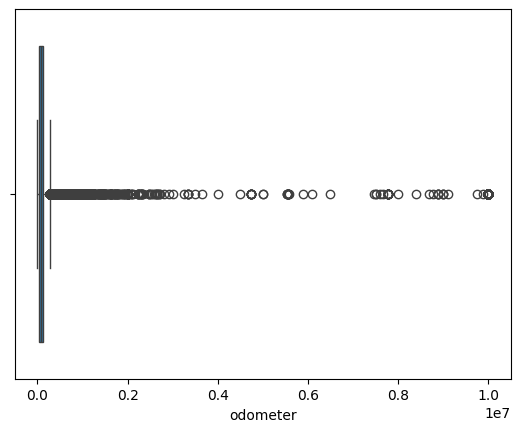

In [73]:
sns.boxplot(data=df, x="odometer")

Лимит: 277300.25
Осталось строк: 418095


<Axes: xlabel='odometer'>

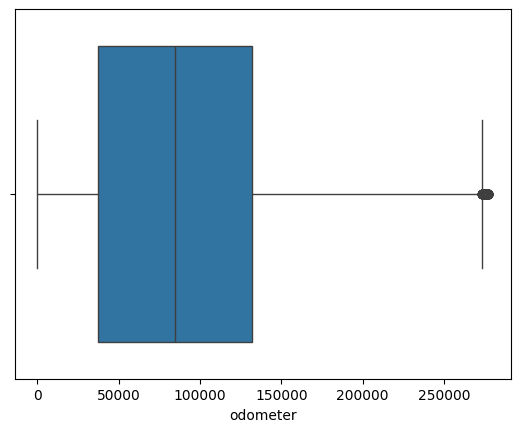

In [74]:
Q1, Q3 = np.nanpercentile(df["odometer"], [25, 75])
IQR = Q3 - Q1
higher_limit = Q3 + 1.5 * IQR

df = df[df["odometer"] < higher_limit]

print(f"Лимит: {higher_limit}")
print(f"Осталось строк: {df.shape[0]}")
sns.boxplot(data=df, x="odometer")


### `year`

<Axes: xlabel='year'>

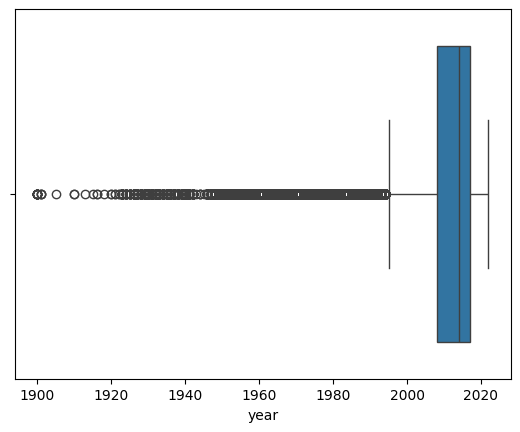

In [75]:
sns.boxplot(data=df, x="year")

In [76]:
Q1, Q3 = np.nanpercentile(df["year"], [25, 75])
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
df = df[df["year"] > lower_limit]

<Axes: xlabel='year'>

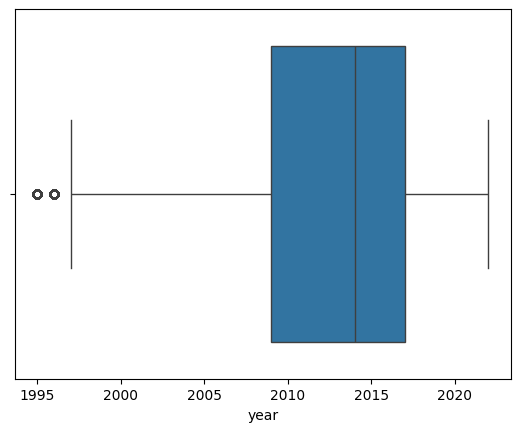

In [77]:
sns.boxplot(data=df, x="year")

### `price`

count    4.017110e+05
mean     6.900708e+04
std      1.215438e+07
min      0.000000e+00
25%      5.995000e+03
50%      1.399900e+04
75%      2.695000e+04
max      3.736929e+09
Name: price, dtype: float64

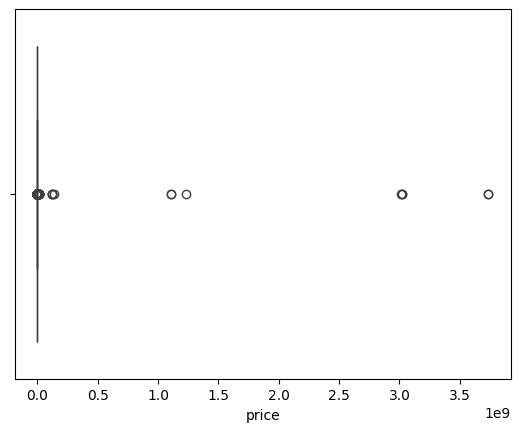

In [78]:
sns.boxplot(data=df, x="price")
df["price"].describe()

In [79]:
print(len(df[(df["price"] > 500) & (df["price"] < 1000)]))

2881


In [80]:
print(len(df[(df["price"] > 100000) & (df["price"] < 125000)]))

251


In [81]:
df = df[(df["price"] > 500) & (df["price"] < 100000)]

Исследование показывает, что границы в 500 и 125000 долларов являются приемлемыми для чистки от выбросов

<Axes: xlabel='price'>

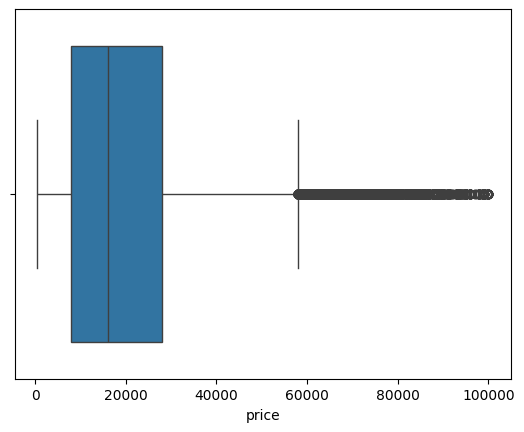

In [82]:
sns.boxplot(data=df, x="price")

In [83]:
df.corr(numeric_only=True)['price']

price           1.000000
year            0.598735
odometer       -0.550076
posting_date         NaN
Name: price, dtype: float64

Используя знания из предметной области, можно сделать вывод: корреляция выглядит естественно.

In [84]:
len(df)

361377

<h2>Работа с пропусками</h2>

In [85]:
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'description', 'posting_date'],
      dtype='str')

In [86]:
def found_miss(df):
  percent_na = np.round(100 * df.isna().sum() / len(df), 2)

  return percent_na[percent_na > 0].sort_values()

C:\Users\egoro\AppData\Local\Temp\ipykernel_6924\3739375903.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");


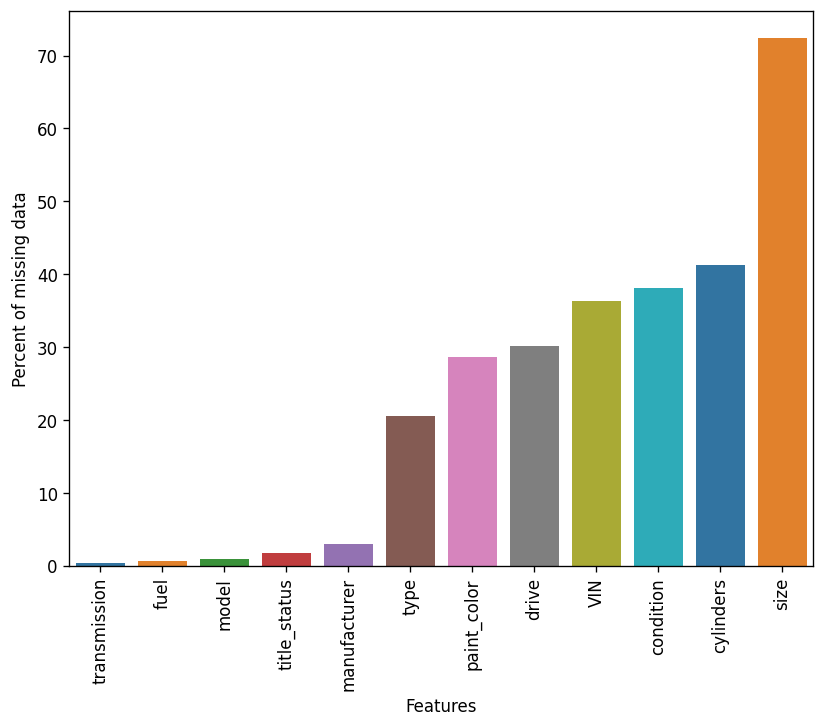

In [87]:
plt.figure(figsize=(8,6), dpi=120);
sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");
plt.xlabel("Features");
plt.ylabel("Percent of missing data");
plt.xticks(rotation=90);
plt.show();

C:\Users\egoro\AppData\Local\Temp\ipykernel_6924\605149035.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");


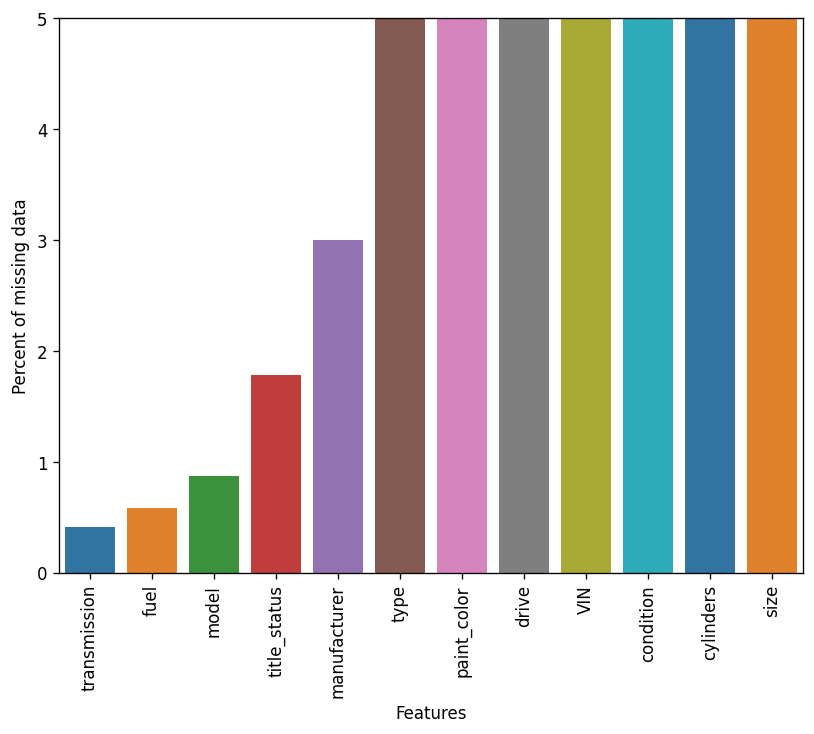

In [88]:
plt.figure(figsize=(8,6), dpi=120);
plt.ylim(0,5)
sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");
plt.xlabel("Features")
plt.ylabel("Percent of missing data")
plt.xticks(rotation=90);
plt.show();

### `transmission`

In [89]:
def fill_mode(x):
    row = x.mode()
    if not row.empty:
        return x.fillna(row[0])
    else:
        return x

In [90]:
print(f"Before:{df["transmission"].isna().sum()}")
df["transmission"] = df.groupby(["manufacturer", "model"], dropna=False)["transmission"].transform(fill_mode)
print(f"After:{df["transmission"].isna().sum()}")
df = df.dropna(subset=["transmission"])

Before:1486
After:64


### `fuel`

In [91]:
print(f"Before:{df["fuel"].isna().sum()}")
df["fuel"] = df.groupby(["manufacturer", "model"], dropna=False)["fuel"].transform(fill_mode)
print(f"After:{df["fuel"].isna().sum()}")
df["fuel"] = df["fuel"].fillna("gas")

Before:2096
After:1395


### `model`

Используя знания из предметной области, делаем вывод: в первых 8-ми числах VIN номера содержится информация о модели автомобиля. 

In [92]:
df["pattern_vin"] = df["VIN"].str[:8]

In [93]:
df["model"] = df.groupby("pattern_vin", dropna=False)["model"].transform(fill_mode)
print(f"Missing: {df["model"].isna().sum()}")
df = df.dropna(subset=["model"])

Missing: 188


In [94]:
df["model"] = df["model"].str.lower().str.strip()
freq = df["model"].value_counts()
freq = freq[freq >= 350].index
df["model"] = df["model"].where(df["model"].isin(freq), "other")

<Axes: xlabel='model', ylabel='count'>

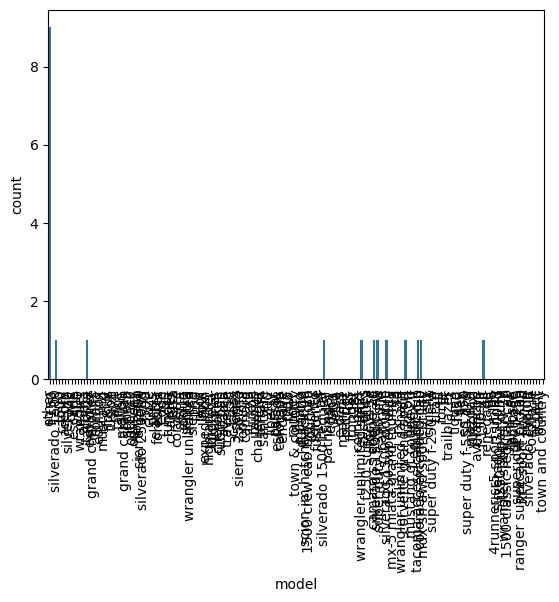

In [95]:
plt.xticks(rotation=90)
sns.countplot(x=df["model"][:20], order=df["model"].value_counts().index)

### `title_status`

Самым близким по смыслу признаком является <b>condition</b>, однако в нём слишком много пропусков, поэтому наиболее подходящим по моему мнению решением является заменить пропуски на <b>unknown</b>

In [96]:
df["title_status"].isna().sum()
df["title_status"] = df["title_status"].fillna("Unknown")

### `manufacturer`

In [97]:
print(f"Before:{df["manufacturer"].isna().sum()}")
df["manufacturer"] = df.groupby("model", dropna=False)["manufacturer"].transform(fill_mode)
print(f"After: {df["manufacturer"].isna().sum()}")

Before:10816
After: 641


In [98]:
print(f"Before:{df["manufacturer"].isna().sum()}")
df["manufacturer"] = df.groupby("pattern_vin", dropna=False)["manufacturer"].transform(fill_mode)
print(f"After: {df["manufacturer"].isna().sum()}")

Before:641
After: 0


<Axes: xlabel='manufacturer', ylabel='count'>

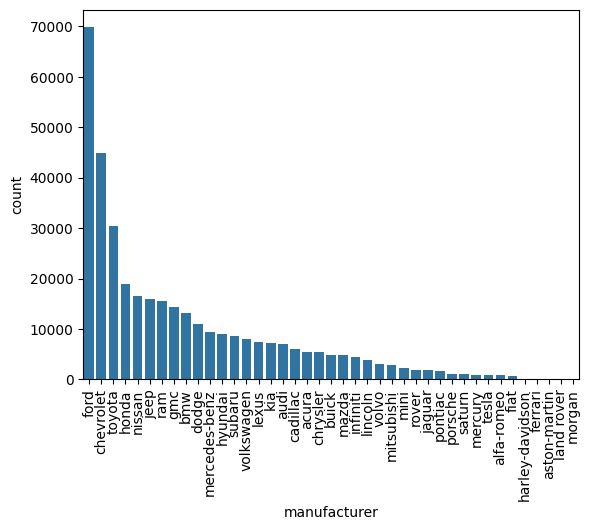

In [99]:
manufacturer_values = df["manufacturer"].value_counts().index
plt.xticks(rotation=90)
sns.countplot(x= df["manufacturer"], order=manufacturer_values)

### `size`

In [100]:
df = df.drop("size", axis=1)

### `type`

C:\Users\egoro\AppData\Local\Temp\ipykernel_6924\2374350663.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df["type"], palette="tab10", order=df["type"].value_counts().index);


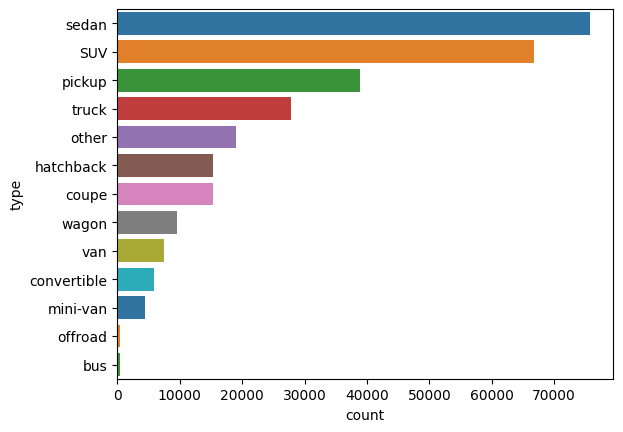

In [101]:
sns.countplot(df["type"], palette="tab10", order=df["type"].value_counts().index);

Используя знания из предметной области, делаем вывод: тип кузова почти всегда определяется первым словом модели

In [102]:
df["model_short"] = df["model"].str.split().str[0].str.strip()

In [103]:
print(f"Before:{df["type"].isna().sum()}")
df["type"] = df.groupby(["manufacturer", "model_short"], dropna=False)["type"].transform(fill_mode)
print(f"After manufacturer and model_short:{df["type"].isna().sum()}")
df["type"] = df.groupby(["model_short", "drive"], dropna=False)["type"].transform(fill_mode)
print(f"After model_short and drive:{df["type"].isna().sum()}")
df["type"] = df["type"].fillna(df["type"].mode()[0])

Before:74351
After manufacturer and model_short:9
After model_short and drive:0


### `paint_color`

In [104]:
print(f"Before:{df["paint_color"].isna().sum()}")
df["paint_color"] = df["paint_color"].fillna(df["paint_color"].mode()[0])
print(f"After:{df["paint_color"].isna().sum()}")

Before:103094
After:0


### `VIN`

In [105]:
df = df.drop(["VIN", "pattern_vin"], axis=1)

### `drive`

In [106]:
print(f"Before:{df["drive"].isna().sum()}")
df["drive"] = df.groupby(["manufacturer", "model_short"], dropna=False)["drive"].transform(fill_mode)
print(f"After manufacturer and model_short:{df["drive"].isna().sum()}")
df["drive"] = df["drive"].fillna(df["drive"].mode()[0])
print(f"After filling with drive:{df["drive"].isna().sum()}")

Before:108861
After manufacturer and model_short:7
After filling with drive:0


In [107]:
df = df.drop("model_short", axis=1)

### `condition`

C:\Users\egoro\AppData\Local\Temp\ipykernel_6924\2136004087.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");


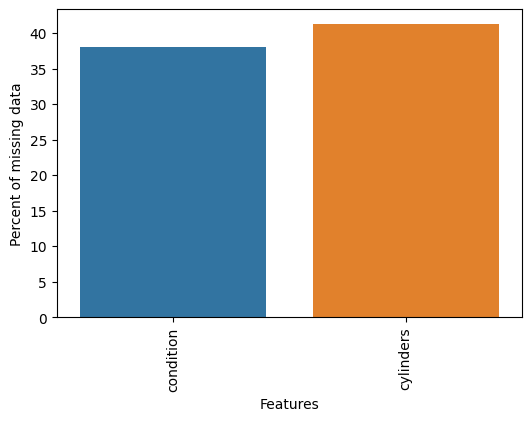

In [108]:
plt.figure(figsize=(6,4), dpi=100);
sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");
plt.xlabel("Features")
plt.ylabel("Percent of missing data")
plt.xticks(rotation=90);
plt.show();

In [109]:
df["condition"].unique()

<StringArray>
['good', 'excellent', 'fair', 'like new', nan, 'new', 'salvage']
Length: 7, dtype: str

In [110]:
def fill_conditions_miles(x):
    if x < 6000: return "High level"
    elif x < 20000: return "Like new"
    elif x < 60000: return "Excellent"
    elif x < 100000: return "Good"
    elif x < 180000: return "Fair"
    return "Salvage"

In [111]:
odomet_cond= df["odometer"].apply(fill_conditions_miles)
df["condition"] = df["condition"].fillna(odomet_cond)

### `cylinders`

In [112]:
df["cylinders"] = df.groupby("model", dropna=False)["cylinders"].transform(fill_mode)
df["cylinders"] = df.groupby("type", dropna=False)["cylinders"].transform(fill_mode)

In [113]:
df["cylinders"] = df["cylinders"].str.split().str[0]
df["cylinders"] = pd.to_numeric(df["cylinders"], errors="coerce")
df["cylinders"] = df["cylinders"].fillna(df["cylinders"].median())

<Axes: xlabel='cylinders'>

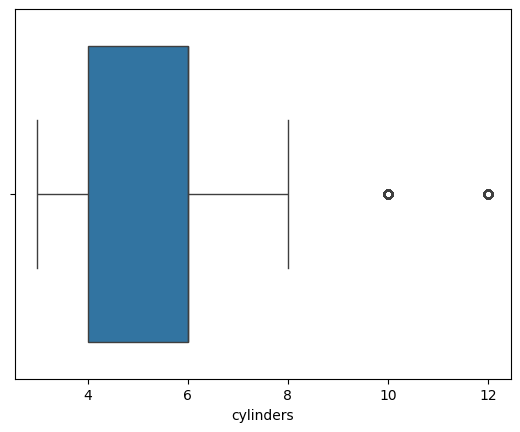

In [114]:
sns.boxplot(data=df, x="cylinders")

In [115]:
df.isna().sum()

region          0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
description     2
posting_date    0
dtype: int64

In [116]:
df = df.dropna()

<Axes: >

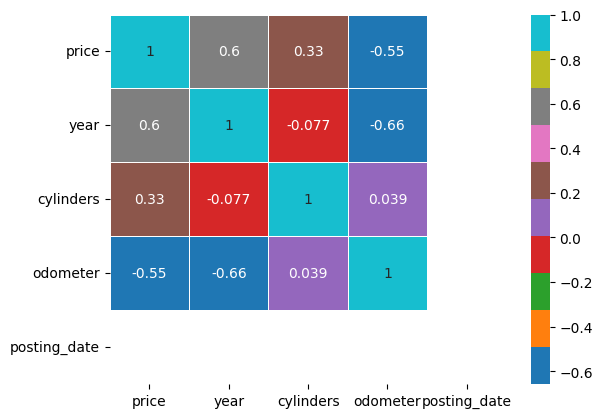

In [117]:
sns.heatmap(data=df.corr(numeric_only=True), annot=True, lw=0.5, cmap="tab10")

In [118]:
len(df)

361123

In [119]:
df.columns.tolist()

['region',
 'price',
 'year',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'odometer',
 'title_status',
 'transmission',
 'drive',
 'type',
 'paint_color',
 'description',
 'posting_date']

In [121]:
list_dummies = ["drive", "title_status", "fuel", "manufacturer", "model", "condition", "paint_color", "type", "transmission"]
for column in list_dummies:
    df = pd.get_dummies(df, columns=[column], drop_first=True, dtype="int")

KeyError: "None of [Index(['drive'], dtype='str')] are in the [columns]"

In [ ]:
len(df.columns)

253

<h2>Linear model</h2>

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = df.drop("price", axis=1)
y = df["price"]

In [ ]:
X_train, X_other, y_train, y_other = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
region_mean = y_train.groupby(X_train["region"]).mean()

X_train["region"] = X_train["region"].map(region_mean)
X_other["region"] = X_other["region"].map(region_mean)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50, stop_words='english')

matrix_train = tfidf.fit_transform(X_train["description"])
matrix_test = tfidf.transform(X_other["description"])

df_matrix_train = pd.DataFrame(matrix_train.toarray(), columns=tfidf.get_feature_names_out(), index=X_train.index)
df_matrix_other = pd.DataFrame(matrix_test.toarray(), columns=tfidf.get_feature_names_out(), index=X_other.index)

X_train = pd.concat([X_train, df_matrix_train], axis=1)
X_other = pd.concat([X_other, df_matrix_other], axis=1)

X_train = X_train.drop("description", axis=1)
X_other = X_other.drop("description", axis=1)

KeyboardInterrupt: 

In [ ]:
X_valid, X_test, y_valid, y_test = train_test_split(X_other, y_other, test_size=0.5, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

lin_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [ ]:
y_pred = lin_pipe.predict(X_valid)

In [ ]:
from sklearn.metrics import root_mean_squared_error

RMSE = root_mean_squared_error(y_valid, y_pred)
mean_price = y.mean()
print(f"Error of LR - {RMSE/mean_price*100:.2f}%")

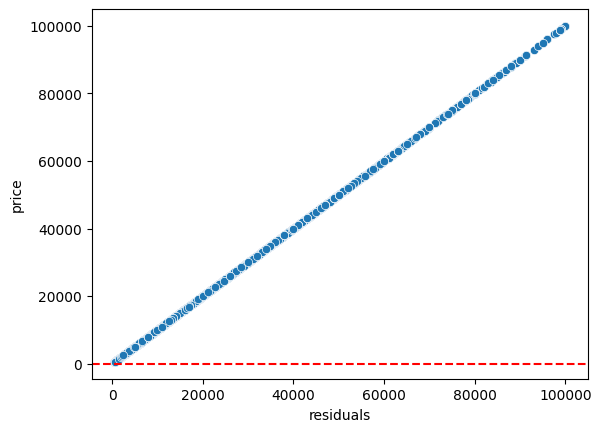

In [ ]:
residuals = y_valid - lin_pipe.predict(X_valid)

sns.scatterplot(x=y_valid, y=residuals)
plt.xlabel("residuals")
plt.axhline(y=0, color="red", ls="--")

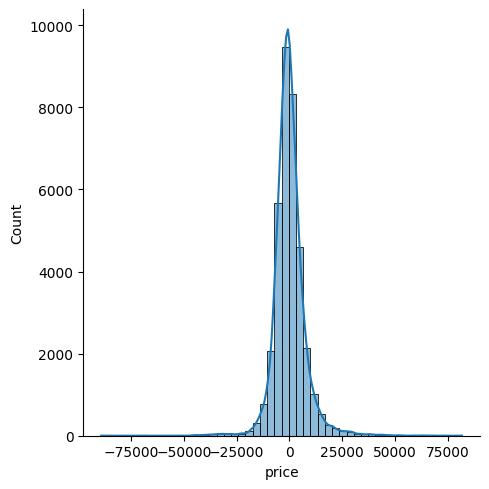

In [ ]:
sns.displot(x=residuals, bins=50, kde=True)

## Отчётность по первой модели линейной регрессии

График остатков показывает, что модель линейной регрессии может не подойти, что исключает перебор гиперпараметров по сетке, однако возможным решением будет логарифмирование целевой переменной из-за эффекта "расширяющейся воронки".

In [ ]:
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

lin_pipe.fit(X_train, y_train_log)
y_pred = np.expm1(lin_pipe.predict(X_valid))

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of LR: {RMSE/mean_price*100:.2f}%")

Error of LR: 37.57%


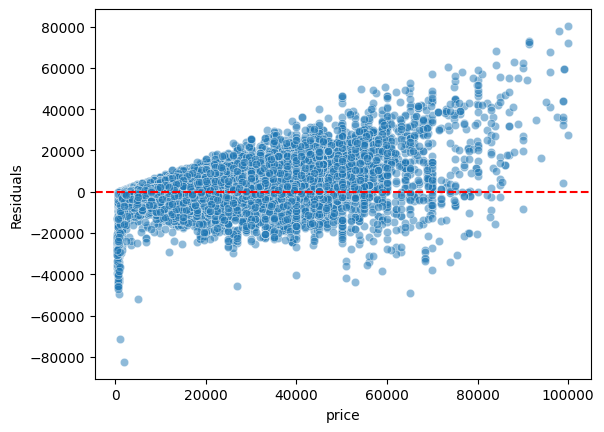

In [ ]:
residuals = y_valid - y_pred

sns.scatterplot(x=y_valid, y=residuals, alpha=0.5)
plt.ylabel("Residuals")
plt.axhline(y=0, color="red", ls="--")

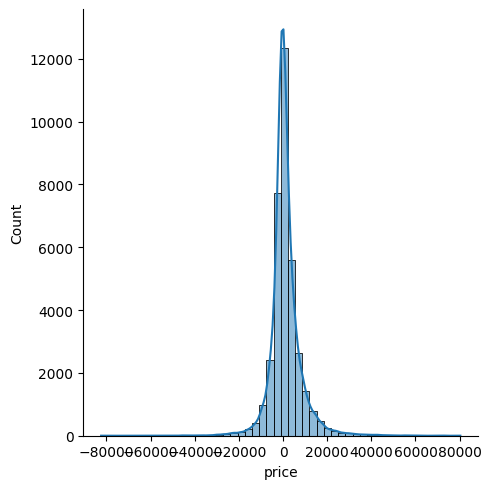

In [ ]:
sns.displot(x=residuals, bins=50, kde=True)

Логарифмирование не исправло ситуацию, переходим к другим алгоритмам

## SVM

In [ ]:
from sklearn.metrics import get_scorer_names

name_scores = get_scorer_name()
print(name_scores)

In [ ]:
from sklearn.svm import LinearSVR

SVR_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("SVR", LinearSVR())
])

param_grid = {
    "SVR__C": [0.01, 0.1, 1, 10, 100],
    "SVR__epsilon": [0.01, 0.1, 0.5, 1],
    "SVR__max_iter": [2000],

}

SVR_grid_model = GridSearchCV(SVR_pipe, param_grid=param_grid, cv=5, verbose=1, scoring="neg_mean_absolute_error")
SVR_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


: 